# Exploratory Data Analysis – Rossmann Store Sales

The goal of this notebook is to explore the Rossmann sales data and understand the main patterns before building a machine learning model. The analysis uses daily sales data from the training and test sets, together with additional store information from the `store` table.

In this notebook, I focus on data structure, missing values, time coverage, and the effect of business variables such as promotions, store type, and day of the week. The main purpose of this EDA is to prepare a good base for feature engineering and later modeling.

In [69]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [107]:
df_train = pd.read_csv('../data/train.csv', low_memory=False)
df_test = pd.read_csv('../data/test.csv')
df_store = pd.read_csv('../data/store.csv')

In [71]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  str   
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(1), str(1)
memory usage: 69.8+ MB


In [72]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 41088 entries, 0 to 41087
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             41088 non-null  int64  
 1   Store          41088 non-null  int64  
 2   DayOfWeek      41088 non-null  int64  
 3   Date           41088 non-null  str    
 4   Open           41077 non-null  float64
 5   Promo          41088 non-null  int64  
 6   StateHoliday   41088 non-null  str    
 7   SchoolHoliday  41088 non-null  int64  
dtypes: float64(1), int64(5), str(2)
memory usage: 2.5 MB


In [73]:
df_store.info()

<class 'pandas.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   str    
 2   Assortment                 1115 non-null   str    
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    str    
dtypes: float64(5), int64(2), str(3)
memory usage: 87.2 KB


In [74]:
print(df_train.shape)
print(df_test.shape)
print(df_store.shape)

(1017209, 9)
(41088, 8)
(1115, 10)


## Data structure

At this stage, it is clear that the problem is based on three connected datasets. The `train` dataset contains historical sales records, the `test` dataset has a similar structure but without the target column `Sales`, and the `store` dataset contains extra information about each store.

Even from this basic overview, two important things can be seen. First, the `Date` column should be converted to a datetime format for time-based analysis. Second, the `store` dataset has missing values, especially in columns related to competition and `Promo2`, which will be important later during preprocessing. 

In [75]:
def merge_store(df_store : pd.DataFrame, df_train : pd.DataFrame) -> pd.DataFrame:
    df_store_copy = df_store.copy()
    df_train_copy = df_train.copy()
    df_train_copy['Date'] = pd.to_datetime(df_train_copy['Date'])
    df_full = pd.merge(df_store_copy, df_train_copy, on='Store', how='left')
    return df_full 

df_train_full = merge_store(df_store, df_train)

In [76]:
df_train_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   StoreType                  1017209 non-null  str           
 2   Assortment                 1017209 non-null  str           
 3   CompetitionDistance        1014567 non-null  float64       
 4   CompetitionOpenSinceMonth  693861 non-null   float64       
 5   CompetitionOpenSinceYear   693861 non-null   float64       
 6   Promo2                     1017209 non-null  int64         
 7   Promo2SinceWeek            509178 non-null   float64       
 8   Promo2SinceYear            509178 non-null   float64       
 9   PromoInterval              509178 non-null   str           
 10  DayOfWeek                  1017209 non-null  int64         
 11  Date                       1017209 non-null  dat

## Merging sales data with store information

To make the analysis more complete, the daily sales data was merged with the `store` table using the `Store` column. Thanks to this, each daily sales record can now be analyzed together with store-level information such as store type, assortment, competition distance, and promotion program details. 

After the merge, the number of rows stays the same as in the training set, so no sales records were lost. At the same time, the merged dataset clearly shows that the biggest missing value problem is in variables related to competition and `Promo2`, so these columns will need special attention later. 

<Axes: >

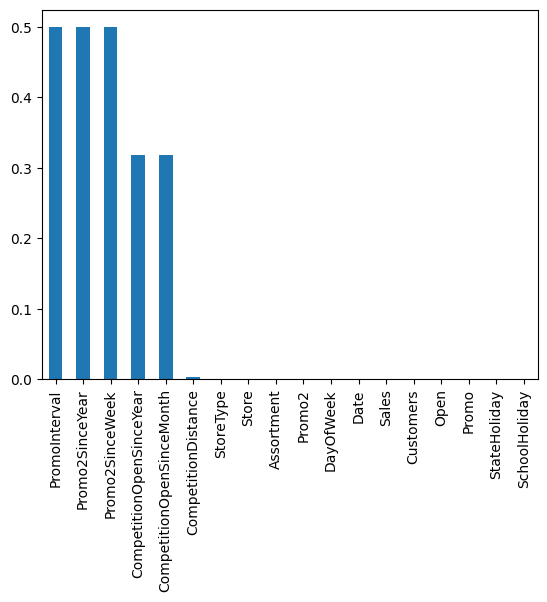

In [77]:
df_train_full.isna().mean().sort_values(ascending=False).plot(kind='bar')

In [97]:
missing = df_train_full.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
pd.DataFrame({'count': missing, 'pct': (missing / len(df_train_full) * 100).round(2)})

,count,pct
Promo2SinceYear,508031,49.94
Promo2SinceWeek,508031,49.94
PromoInterval,508031,49.94
CompetitionOpenSinceMonth,323348,31.79
CompetitionOpenSinceYear,323348,31.79
CompetitionDistance,2642,0.26


## Missing values

The missing values are not random and mostly appear in business-related columns connected to competition and `Promo2`. This may mean that the missing value itself contains useful information, for example no nearby competition or no participation in the `Promo2` program, instead of being only a technical data quality issue. 

From a modeling point of view, this is important because some missing values may be better treated as meaningful information instead of being filled with a simple average or median. In the next steps, it may be useful to test both standard imputation and extra flags showing where data is missing. 

In [78]:
print(df_train_full['Date'].min())
print(df_train_full['Date'].max())

2013-01-01 00:00:00
2015-07-31 00:00:00


In [79]:
print(df_train_full['Store'].nunique())

1115


In [80]:
print(df_train_full['DayOfWeek'].nunique())

7


In [81]:
def count_sales_per_date(df):
    df_copy = df.copy()
    result = df_copy.groupby('Date')['Sales'].count().reset_index()
    return result 

res = count_sales_per_date(df_train_full)

print(res.sort_values(by=['Sales'], ascending=False))
print(res['Sales'].min())
print(res['Sales'].max())

          Date  Sales
941 2015-07-31   1115
940 2015-07-30   1115
1   2013-01-02   1115
2   2013-01-03   1115
3   2013-01-04   1115
..         ...    ...
551 2014-07-06    935
553 2014-07-08    935
554 2014-07-09    935
555 2014-07-10    935
556 2014-07-11    935

[942 rows x 2 columns]
935
1115


## Time range and data coverage

The data covers the period from the beginning of 2013 to the end of July 2015 and includes records for 1115 stores. The `DayOfWeek` variable includes all 7 days, which means the model will be able to use weekly patterns in sales. 

At the same time, the number of records per date is not always the same, so not every day contains data for all stores. This may be caused by store closures, missing observations, or the general structure of the dataset, and it is something to remember when looking at trends over time.

In [82]:
def basic_stats(df):
    df_copy = df.copy()
    df1 = df_copy[df_copy['Open'] == 0]
    records_open_zero = len(df1) 
    records_sales_zero = len(df1[df1['Sales'] == 0])
    records_open_zero_sales = len(df1[df1['Sales'] > 0])
    return records_open_zero, records_sales_zero, records_open_zero_sales

print(basic_stats(df_train_full))

(172817, 172817, 0)


In [108]:
def open_equal_zero(df):
    return f'Percentage of the shops with Open=0: {round(len(df[df['Open'] == 0]) / len(df) * 100, 2)}%'

print(open_equal_zero(df_train_full))

Percentage of the shops with Open=0: 16.99%


## Closed stores and zero sales

A noticeable part of the dataset contains records where the store was closed, which is shown by rows with `Open == 0`. It is also important that there are no cases where a store is marked as closed but still has positive sales, so the data looks logically consistent in this part. 

This matters because closed-store days should not be treated as simple noise. From a business and modeling point of view, they represent a different store state, and this information will probably be very useful in the final prediction pipeline. 

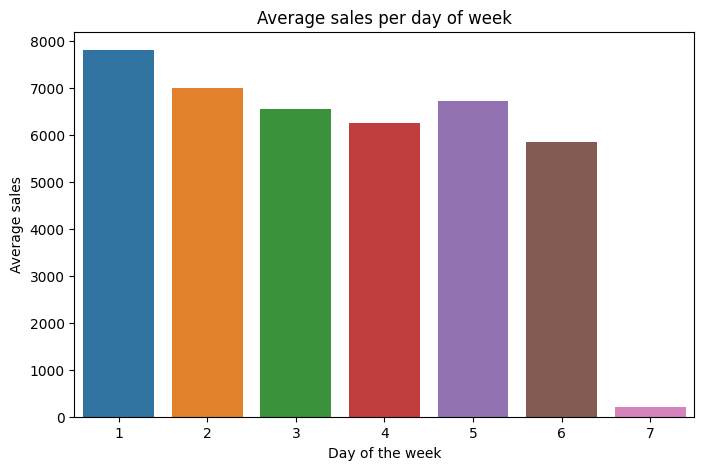

In [84]:
data = df_train_full.groupby('DayOfWeek')['Sales'].mean().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(
    data=data, 
    x='DayOfWeek', 
    y='Sales', 
    hue='DayOfWeek', 
    palette='tab10',
    legend=False
)
plt.title('Average sales per day of week')
plt.xlabel('Day of the week')
plt.ylabel('Average sales')
plt.xticks(rotation=0)
plt.show()

## Sales by day of the week

The chart shows clear differences in average sales between days of the week, which means that weekly seasonality is present in the data. In other words, sales behavior changes depending on the position of the day within the weekly cycle. 

From a practical point of view, `DayOfWeek` should stay in the model as one of the basic calendar features. Even at this early stage, it looks like an important variable that can help the model capture repeating sales patterns. 

In [90]:
df_without_promo = df_train_full[df_train_full['Promo'] == 0]
df_with_promo = df_train_full[df_train_full['Promo'] == 1]

print(f'Average sales without promo: {df_without_promo['Sales'].mean()}')
print(f'Average sales with promo: {df_with_promo['Sales'].mean()}')
print(f'Median sales without promo: {df_without_promo['Sales'].median()}')
print(f'Median sales with promo: {df_with_promo['Sales'].median()}')



Average sales without promo: 4406.050805160786
Average sales with promo: 7991.152045969903
Median sales without promo: 4622.0
Median sales with promo: 7553.0


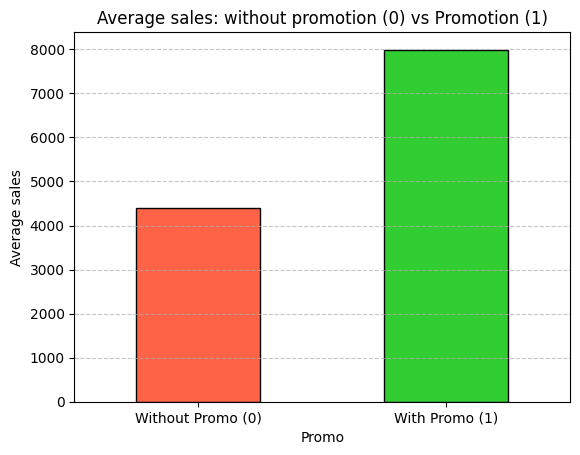

In [93]:
promo_stats = df_train_full.groupby('Promo')['Sales'].agg(['mean', 'median', 'count'])

promo_stats['mean'].plot(kind='bar', color=['tomato', 'limegreen'], edgecolor='black')
plt.title('Average sales: without promotion (0) vs Promotion (1)')
plt.xlabel('Promo')
plt.ylabel('Average sales')
plt.xticks(ticks=[0, 1], labels=['Without Promo (0)', 'With Promo (1)'], rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

## Sales and promotions

Promotions are one of the business variables that should have a strong effect on sales, so it makes sense to compare the basic sales statistics for promo and non-promo days. The difference in average and median sales shows that the relationship is not simple and should be interpreted carefully, because the promo effect may also depend on store type, calendar effects, and whether the store was open on that day. 

At this stage, the main conclusion is that `Promo` is too important to ignore in the model. In the next steps, it would be useful to study this variable in more detail, especially together with other store and time features. 

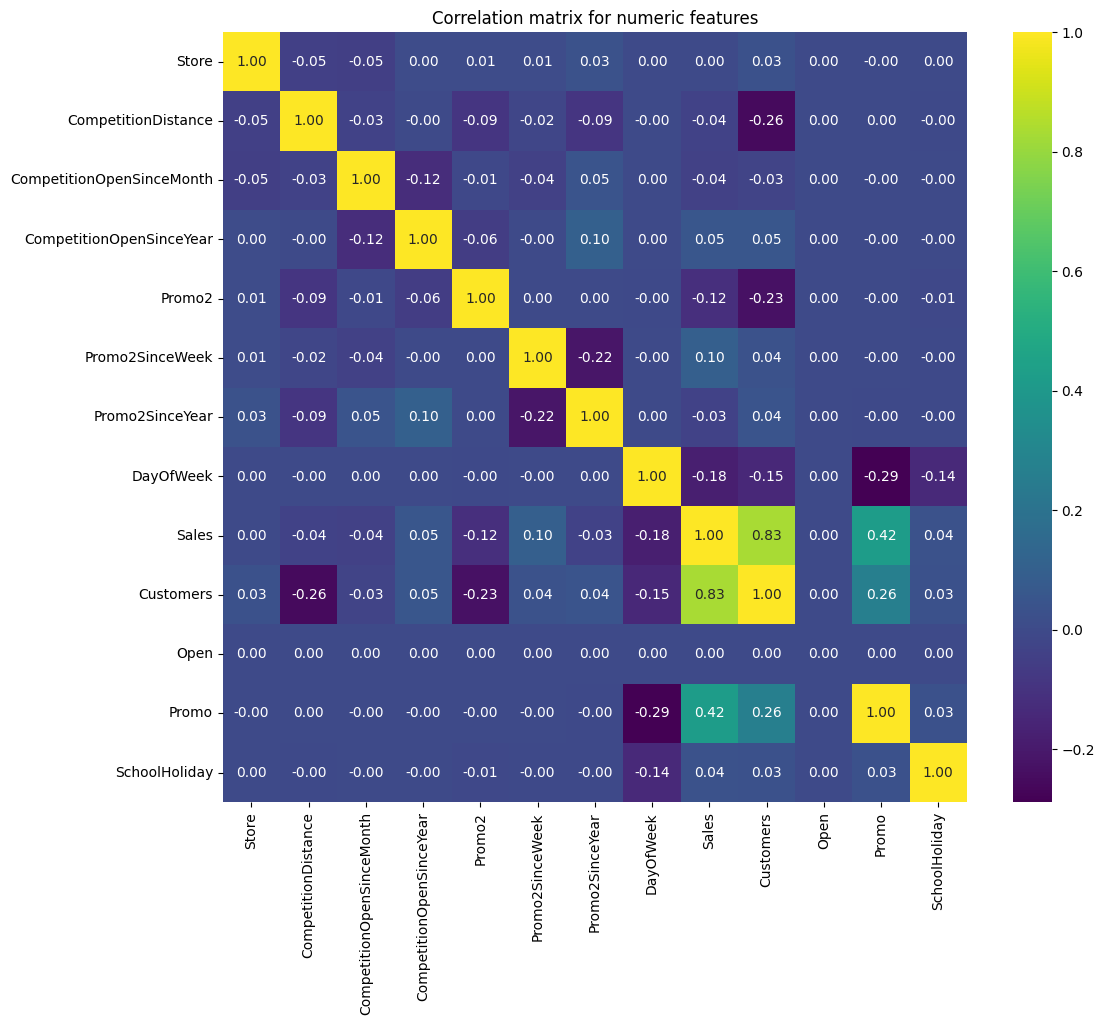

In [92]:
df_open = df_train_full[df_train_full['Open'] == 1]
corr_matrix = df_open.select_dtypes(include='number').corr('spearman').fillna(0)

plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='viridis')
plt.title('Correlation matrix for numeric features')
plt.show()


## Correlations between numerical variables

The Spearman correlation matrix gives a quick overview of which numerical variables move together in a monotonic way. It does not prove cause and effect, but it helps show which features may carry similar information or may be connected to sales. 

At the EDA stage, this heatmap is mainly a support tool. It is useful for finding variables that may be important later for feature selection, feature creation, or deeper analysis. 

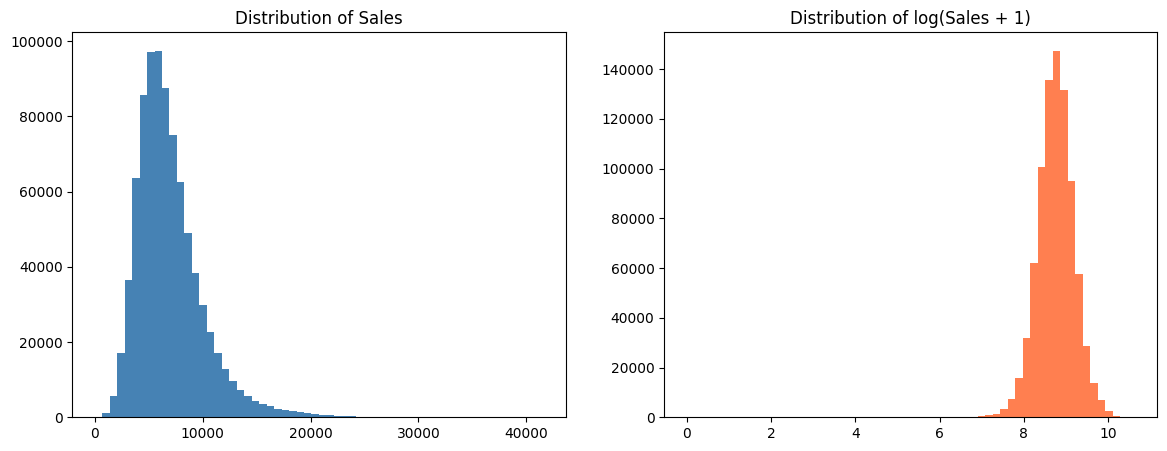

count    844392.000000
mean       6955.514291
std        3104.214680
min           0.000000
25%        4859.000000
50%        6369.000000
75%        8360.000000
max       41551.000000
Name: Sales, dtype: float64


In [96]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df_open['Sales'], bins=60, color='steelblue')
axes[0].set_title('Distribution of Sales')
axes[1].hist(np.log1p(df_open['Sales']), bins=60, color='coral')
axes[1].set_title('Distribution of log(Sales + 1)')
plt.show()
print(df_open['Sales'].describe())

## Sales distribution

The distribution of sales on open days is right-skewed, which is typical
for retail data. The log-transformed version is closer to a normal
distribution, which suggests that log(Sales + 1) may be a better target
for regression models. At prediction time, the transformation is reversed
with expm1(). The minimum value of 0 in the describe output comes from
open stores with no sales — worth investigating separately.

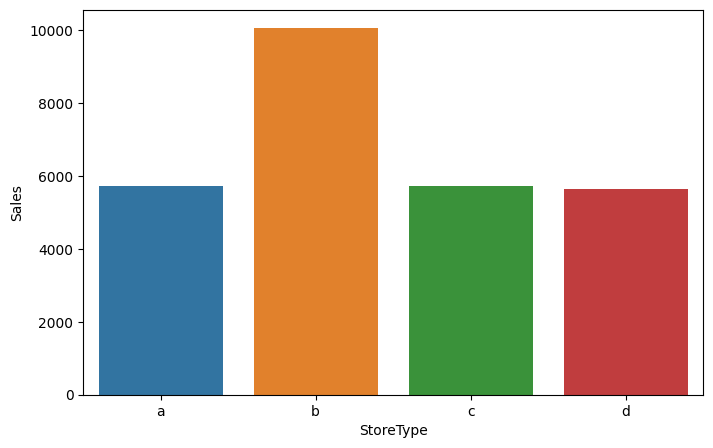

In [88]:
data = df_train_full.groupby('StoreType')['Sales'].mean().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(
    data = data, 
    x='StoreType', 
    y='Sales', 
    hue='StoreType',
    palette='tab10', 
    legend=False
)
plt.show()

Text(0.5, 1.0, 'Promo effect by StoreType')

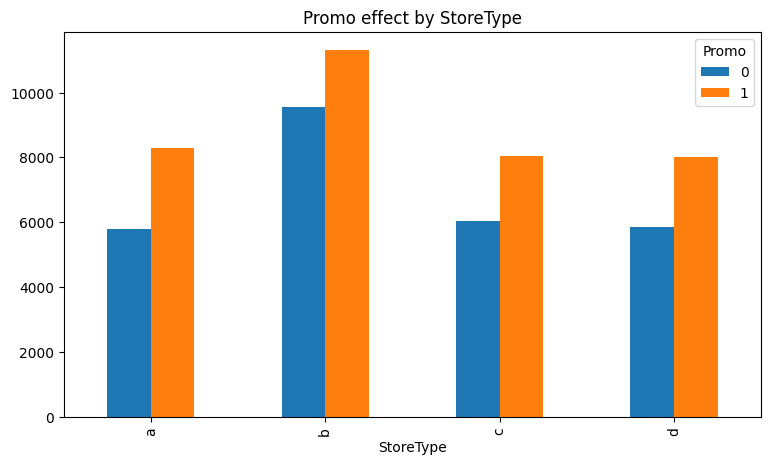

In [106]:
df_open.groupby(['StoreType', 'Promo'])['Sales'].mean().unstack().plot(kind='bar', figsize=(9,5))
plt.title('Promo effect by StoreType')

## Sales by store type

Store type clearly changes the average sales level, which confirms that
stores are not a uniform group. More importantly, the promo effect is not
the same across store types — some types react much stronger to promotions
than others. This interaction between StoreType and Promo is a good
candidate for a feature in the model.

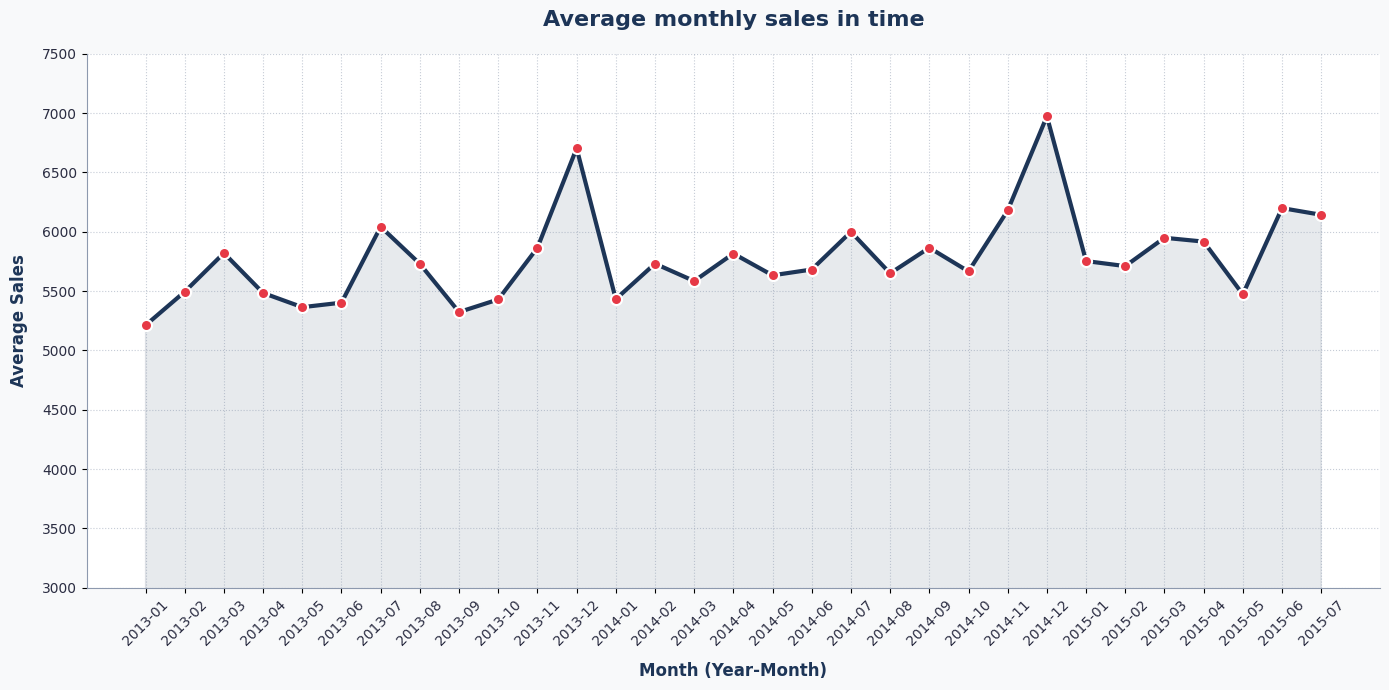

In [94]:
df_train_full['YearMonth'] = df_train_full['Date'].dt.to_period('M')
monthly_sales = df_train_full.groupby('YearMonth')['Sales'].mean()
monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(14, 7), facecolor='#f8f9fa')
ax = plt.axes()
ax.set_facecolor('#ffffff')

line_color = '#1d3557'

plt.plot(
    monthly_sales.index, 
    monthly_sales.values, 
    color=line_color, 
    linewidth=3, 
    marker='o', 
    markersize=8, 
    markerfacecolor='#e63946', 
    markeredgecolor='#ffffff', 
    markeredgewidth=1.5,
    label='Średnia sprzedaż'
)

plt.fill_between(
    monthly_sales.index, 
    monthly_sales.values, 
    color=line_color, 
    alpha=0.1
)

plt.xticks(range(len(monthly_sales)), monthly_sales.index, rotation=45, fontsize=10, color='#2b2d42')
plt.yticks(fontsize=10, color='#2b2d42')

plt.title('Average monthly sales in time', fontsize=16, fontweight='bold', pad=20, color='#1d3557')
plt.xlabel('Month (Year-Month)', fontsize=12, fontweight='semibold', labelpad=10, color='#1d3557')
plt.ylabel('Average Sales', fontsize=12, fontweight='semibold', labelpad=10, color='#1d3557')
plt.ylim(3000, 7500)
plt.grid(True, linestyle=':', alpha=0.5, color='#8d99ae')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#8d99ae')
ax.spines['bottom'].set_color('#8d99ae')

plt.tight_layout()
plt.show()

## Monthly sales trend over time

Average monthly sales change over time, which suggests that the data contains not only store differences and weekly effects, but also a longer trend and possible seasonality. This kind of chart is useful because it quickly shows whether the sales level stays stable or changes across months. 

For modeling, this is a good reason to create date-based features such as month, quarter, or year. The date should not be treated only as an identifier, but also as a source of useful information about sales patterns over time.

Text(0.5, 1.0, 'Monthly sales pattern by year')

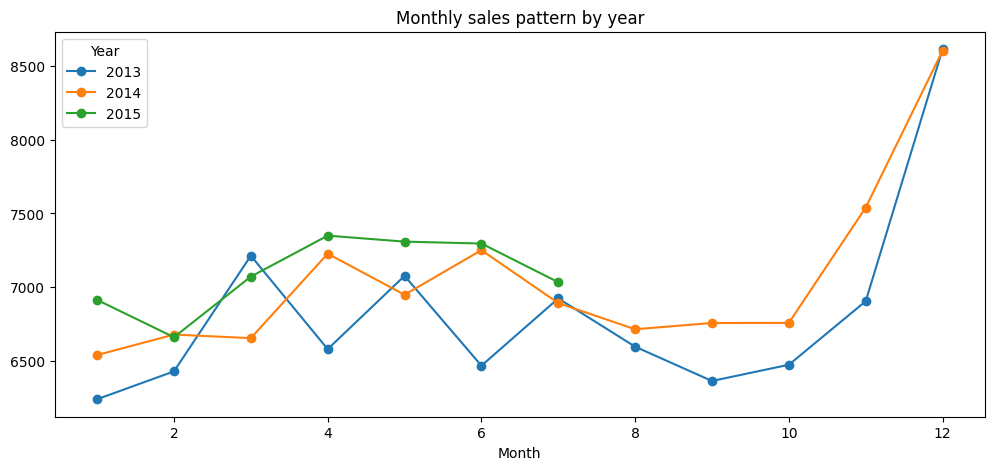

In [98]:
df_open['Year']  = df_open['Date'].dt.year
df_open['Month'] = df_open['Date'].dt.month
df_open.groupby(['Year', 'Month'])['Sales'].mean().unstack(0).plot(figsize=(12,5), marker='o')
plt.title('Monthly sales pattern by year')

## Seasonal patterns

Breaking monthly sales by year shows whether the seasonal pattern repeats
consistently. If the shape is similar across 2013, 2014, and 2015, it
confirms stable yearly seasonality that the model can learn from calendar
features like month and quarter.

Text(0.5, 1.0, 'Avg Sales: Day of Week × Month')

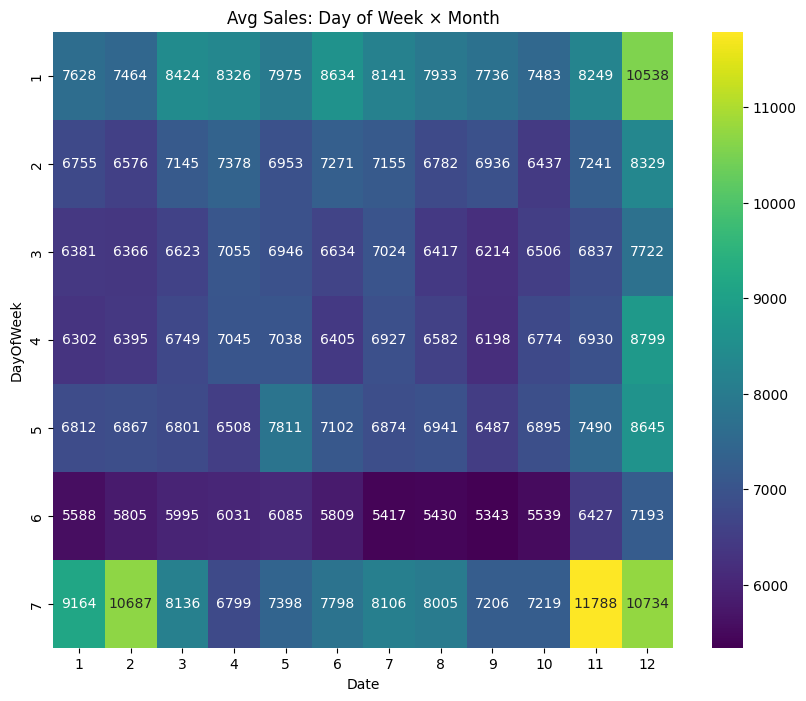

In [105]:
pivot = df_open.groupby(['DayOfWeek', df_open['Date'].dt.month])['Sales'].mean().unstack()
plt.figure(figsize=(10,8))
sns.heatmap(pivot, cmap='viridis', annot=True, fmt='.0f')
plt.title('Avg Sales: Day of Week × Month')

## Day of week × month interaction

The heatmap shows average sales for every combination of day of week and
month. This reveals whether the weekly pattern is stable across the year
or changes by season. Strong variation across both axes is a signal that
an interaction feature between DayOfWeek and Month could add value in
modeling.

## Key findings

- The data combines daily sales records with store-level information, which makes it possible to analyze both time patterns and differences between stores. 
- The biggest missing value problem appears in variables related to competition and `Promo2`, and these missing values may have business meaning instead of being only a technical issue. 
- The dataset covers a long time period and includes all 7 days of the week, which makes it possible to study both trend and weekly seasonality. 
- Rows with `Open == 0` form an important part of the dataset and are logically consistent with zero sales, which suggests that store availability will be an important feature for the model. 
- Day of the week has a clear effect on sales, which confirms the presence of a weekly calendar pattern. 
- Business variables such as promotions and store type have strong potential to explain part of the sales differences and should be kept in the later analysis. 
- Changes in average sales over time suggest that the date should be used as a source of trend and seasonality features. 

## Next steps

The next step should be feature engineering and data preparation for modeling. The most natural directions are:

- creating calendar features such as month, week, quarter, and year,
- preparing a reasonable strategy for missing values,
- encoding categorical store variables,
- modeling the relationship between promotions, store opening, and calendar effects,
- creating more advanced time-related features if the model should capture sales dynamics more deeply. 